In [ ]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import info
import loader
import stats
import plotter

dataset_path = "../dataset/processed/features.csv"
    
try:
    df = loader.load_data(dataset_path)
except FileNotFoundError as e:
    print(f"Error: dataset file ({dataset_path}) not found")
    sys.exit(1)

### Contare lingue per valore di una feature

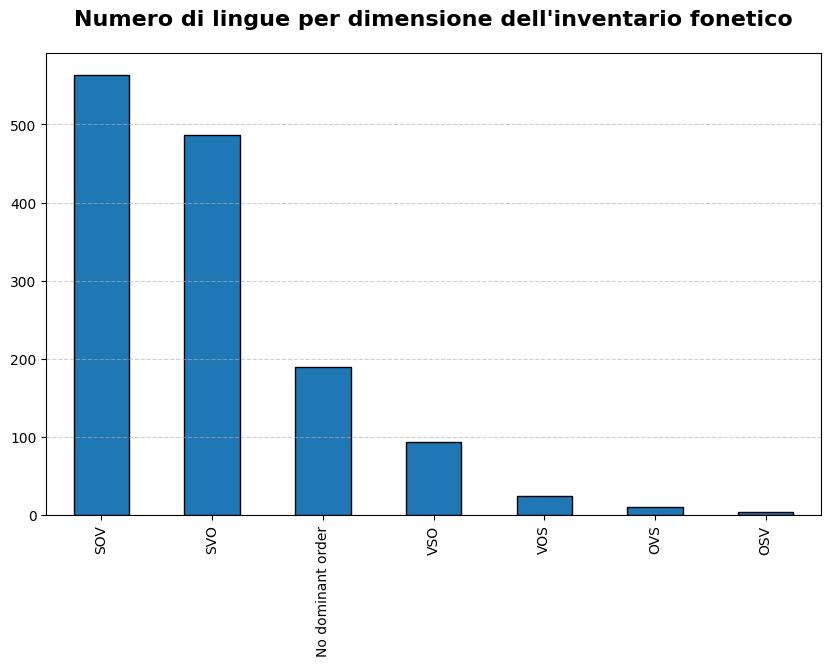

In [2]:
parameter_id = "81A"
qdf = df.copy()
qdf = qdf[qdf["Parameter_ID"] == parameter_id]
qdf = qdf.groupby("Code_Name")["Language_ID"].nunique().sort_values(ascending=False)

plotter.bar_plot(
    qdf,
    title="Numero di lingue per dimensione dell'inventario fonetico",
)

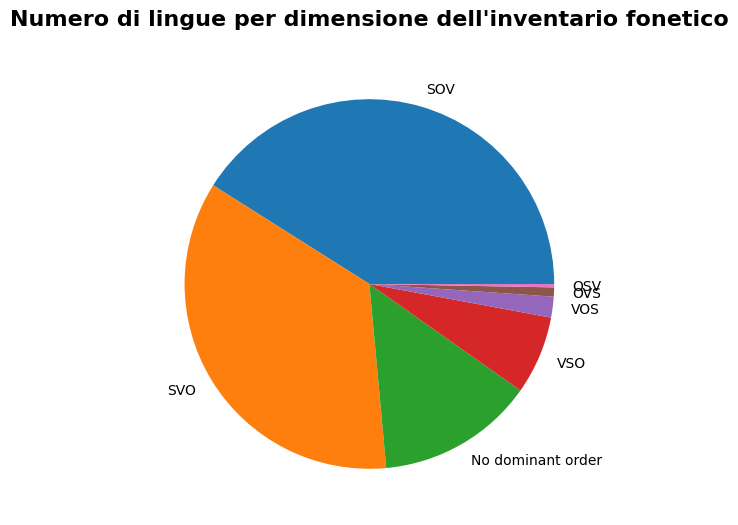

In [3]:
parameter_id = "81A"
qdf = df.copy()
qdf = qdf[qdf["Parameter_ID"] == parameter_id]
qdf = qdf.groupby("Code_Name")["Language_ID"].nunique().sort_values(ascending=False)

plotter.pie_plot(
    qdf,
    title="Numero di lingue per dimensione dell'inventario fonetico",
)

### Conto lingue per valore di feature divise in famiglia linguistica

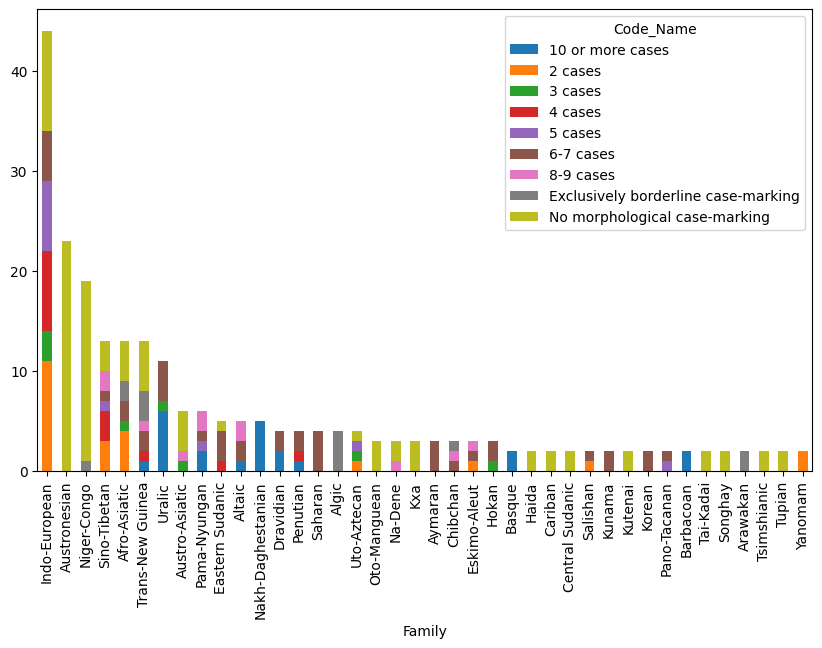

In [4]:
feature_id = "49A"

qdf = df.copy()
qdf = stats.filter(qdf, "Parameter_ID", [feature_id])
qdf = pd.crosstab(qdf["Family"], qdf["Code_Name"])

n_top = 40
qdf = qdf.assign(Total=qdf.sum(axis=1))

qdf = qdf.drop(index="other")

languages_by_family = qdf.sort_values("Total", ascending=False)
languages_by_family = languages_by_family.drop("Total", axis=1)

chunk = stats.get_chunks(languages_by_family, 40)[0]

plotter.stacked_bar_plot(chunk)

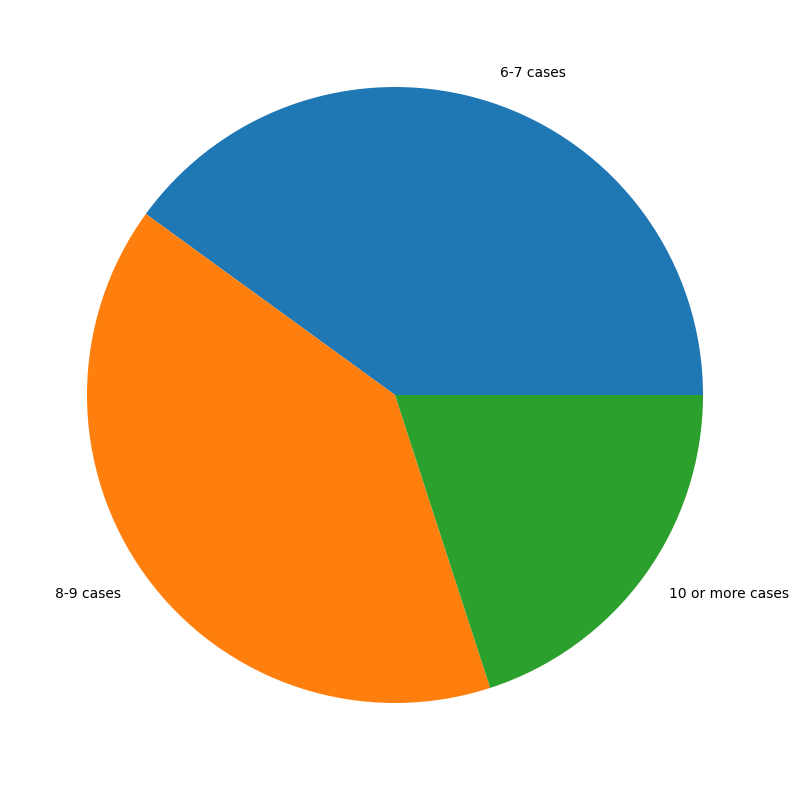

In [7]:
family_name = "Altaic"
feature_id = "49A"

qdf = df.copy()
qdf = stats.filter(qdf, "Family", [family_name])
qdf = stats.filter(qdf, "Parameter_ID", [feature_id])
qdf = qdf.groupby("Code_Name")["Language_ID"].nunique().sort_values(ascending=False)

plotter.pie_plot(
    qdf,
    figsize=(10, 10)
)